In [3]:
import sys
!{sys.executable} -m pip install scipy

  Using cached scipy-1.18.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 1.5 MB/s  0:00:14m0:00:0100:01


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [6]:
nav = pd.read_csv("/Users/amritrajgupta/Desktop/Bluestock Capstone/Data/Processed/clean_nav.csv")

performance = pd.read_csv("../Data/Processed/clean_performance.csv")

fund = pd.read_csv("../Data/Raw/01_fund_master.csv")

print("Datasets Loaded Successfully!")

Datasets Loaded Successfully!


In [7]:
nav["date"] = pd.to_datetime(nav["date"])

nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [8]:
nav = nav.sort_values(
    by=["amfi_code", "date"]
)

In [9]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [10]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [11]:
annual_return = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(
           lambda x: (
               (1 + x.dropna()).prod()
           ) ** (252 / len(x.dropna())) - 1
       )
       .reset_index()
)

annual_return.columns = [
    "amfi_code",
    "annualised_return"
]

annual_return.head()

,amfi_code,annualised_return
0,100016,0.025435
1,100025,0.042987
2,100033,0.289279
3,101206,0.226265
4,101207,0.076502


In [12]:
annual_return.to_csv(
    "../Reports/returns_computed.csv",
    index=False
)

print("returns_computed.csv saved successfully!")

returns_computed.csv saved successfully!


In [13]:
import os

print(os.path.exists("../Reports/returns_computed.csv"))

True


In [14]:
# Get first and last NAV for each fund
cagr = (
    nav.groupby("amfi_code")
    .agg(
        start_nav=("nav", "first"),
        end_nav=("nav", "last"),
        start_date=("date", "first"),
        end_date=("date", "last")
    )
    .reset_index()
)

# Calculate number of years
cagr["years"] = (
    (cagr["end_date"] - cagr["start_date"]).dt.days
) / 365.25

# CAGR Formula
cagr["cagr"] = (
    (cagr["end_nav"] / cagr["start_nav"])
    ** (1 / cagr["years"])
) - 1

cagr.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,cagr
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.399726,0.026371
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.399726,0.044582
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.399726,0.301232
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.399726,0.235384
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.399726,0.079388


In [15]:
cagr = cagr.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr = cagr[
    [
        "amfi_code",
        "scheme_name",
        "start_nav",
        "end_nav",
        "years",
        "cagr"
    ]
]

cagr.head()

,amfi_code,scheme_name,start_nav,end_nav,years,cagr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,520.4608,583.6113,4.399726,0.026371
1,100025,HDFC Short Term Debt Fund - Regular - Growth,26.3169,31.8843,4.399726,0.044582
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,107.3758,342.0072,4.399726,0.301232
3,101206,ABSL Frontline Equity Fund - Regular - Growth,305.0996,773.2939,4.399726,0.235384
4,101207,ABSL Small Cap Fund - Regular - Growth,38.5736,53.9836,4.399726,0.079388


In [16]:
cagr["cagr_pct"] = cagr["cagr"] * 100

In [17]:
cagr.to_csv(
    "../Reports/cagr_report.csv",
    index=False
)

print("cagr_report.csv saved successfully!")

cagr_report.csv saved successfully!


## CAGR Analysis

- CAGR measures the annualised growth rate of each mutual fund.
- It smooths out year-to-year fluctuations and provides a consistent measure of long-term performance.
- Higher CAGR values indicate stronger long-term growth.

In [18]:
risk_free_rate = 0.065

In [19]:
sharpe = (
    nav.groupby("amfi_code")
    .agg(
        annual_return=("daily_return", lambda x: (1 + x.dropna()).prod() ** (252 / len(x.dropna())) - 1),
        daily_std=("daily_return", "std")
    )
    .reset_index()
)

# Annualize standard deviation
sharpe["annual_std"] = sharpe["daily_std"] * np.sqrt(252)

# Sharpe Ratio
sharpe["sharpe_ratio"] = (
    (sharpe["annual_return"] - risk_free_rate)
    / sharpe["annual_std"]
)

sharpe.head()

,amfi_code,annual_return,daily_std,annual_std,sharpe_ratio
0,100016,0.025435,0.009164,0.145481,-0.271960
1,100025,0.042987,0.002460,0.039052,-0.563690
2,100033,0.289279,0.011929,0.189367,1.184359
3,101206,0.226265,0.009177,0.145682,1.106967
4,101207,0.076502,0.016251,0.257973,0.044584


In [20]:
sharpe = sharpe.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sharpe = sharpe[
    [
        "amfi_code",
        "scheme_name",
        "annual_return",
        "annual_std",
        "sharpe_ratio"
    ]
]

sharpe.head()

,amfi_code,scheme_name,annual_return,annual_std,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.025435,0.145481,-0.271960
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042987,0.039052,-0.563690
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.289279,0.189367,1.184359
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.226265,0.145682,1.106967
4,101207,ABSL Small Cap Fund - Regular - Growth,0.076502,0.257973,0.044584


In [21]:
sharpe.to_csv(
    "../Reports/sharpe_values.csv",
    index=False
)

print("sharpe_values.csv saved successfully!")

sharpe_values.csv saved successfully!


## Sharpe Ratio Analysis

- Sharpe Ratio measures return generated per unit of total risk.
- Higher Sharpe Ratios indicate better risk-adjusted performance.
- A positive Sharpe Ratio suggests that the fund outperformed the risk-free rate after adjusting for volatility.

In [22]:
sortino = (
    nav.groupby("amfi_code")
    .apply(
        lambda df: pd.Series({
            "annual_return": (1 + df["daily_return"].dropna()).prod() ** (252 / len(df["daily_return"].dropna())) - 1,
            "downside_std": df.loc[df["daily_return"] < 0, "daily_return"].std() * np.sqrt(252)
        })
    )
    .reset_index()
)

sortino["sortino_ratio"] = (
    (sortino["annual_return"] - risk_free_rate)
    / sortino["downside_std"]
)

sortino.head()

,amfi_code,annual_return,downside_std,sortino_ratio
0,100016,0.025435,0.083513,-0.473761
1,100025,0.042987,0.023514,-0.936166
2,100033,0.289279,0.113229,1.980757
3,101206,0.226265,0.083157,1.939283
4,101207,0.076502,0.151683,0.075827


In [23]:
sortino = sortino.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino = sortino[
    [
        "amfi_code",
        "scheme_name",
        "annual_return",
        "downside_std",
        "sortino_ratio"
    ]
]

sortino.head()

,amfi_code,scheme_name,annual_return,downside_std,sortino_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.025435,0.083513,-0.473761
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042987,0.023514,-0.936166
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.289279,0.113229,1.980757
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.226265,0.083157,1.939283
4,101207,ABSL Small Cap Fund - Regular - Growth,0.076502,0.151683,0.075827


In [24]:
sortino.to_csv(
    "../Reports/sortino_values.csv",
    index=False
)

print("sortino_values.csv saved successfully!")

sortino_values.csv saved successfully!


## Sortino Ratio Analysis

- The Sortino Ratio measures return generated per unit of downside risk.
- Unlike the Sharpe Ratio, it ignores positive volatility and focuses only on harmful fluctuations.
- Higher Sortino Ratios indicate better downside risk-adjusted performance.

In [25]:
benchmark = pd.read_csv("../Data/Raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [26]:
benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


In [27]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [28]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [29]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [30]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [31]:
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [32]:
merged = nav.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,-0.013540
2,100016,2022-01-05,521.7239,0.012865,0.004003
3,100016,2022-01-06,515.7880,-0.011377,-0.002935
4,100016,2022-01-07,515.1639,-0.001210,0.006150


In [33]:
alpha_beta = []

for fund_code, group in merged.groupby("amfi_code"):

    df = group.dropna(subset=["daily_return", "benchmark_return"])

    if len(df) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        df["benchmark_return"],
        df["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": fund_code,
        "alpha": intercept * 252,
        "beta": slope
    })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [34]:
alpha_beta = alpha_beta.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta = alpha_beta[
    [
        "amfi_code",
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.head()

,amfi_code,scheme_name,alpha,beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.037476,-0.058268
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042818,0.001158
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.213998,0.021086
4,101207,ABSL Small Cap Fund - Regular - Growth,0.108971,-0.065289


In [35]:
alpha_beta.to_csv(
    "../Reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully!")

alpha_beta.csv saved successfully!


In [36]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [37]:
# Running maximum NAV for each fund
nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

In [38]:
nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

In [39]:
max_drawdown = (
    nav.groupby("amfi_code")
       .agg(
           max_drawdown=("drawdown", "min")
       )
       .reset_index()
)

max_drawdown.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [40]:
max_drawdown = max_drawdown.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

max_drawdown = max_drawdown[
    [
        "amfi_code",
        "scheme_name",
        "max_drawdown"
    ]
]

max_drawdown.head()

,amfi_code,scheme_name,max_drawdown
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.162172
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.112916
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.354469


In [41]:
max_drawdown.to_csv(
    "../Reports/max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved successfully!")

max_drawdown.csv saved successfully!


## Maximum Drawdown Analysis

- Maximum Drawdown represents the largest decline in NAV from a historical peak.
- Funds with smaller drawdowns are generally more resilient during market downturns.
- Investors often use Maximum Drawdown alongside return metrics to assess downside risk.

In [42]:
scorecard = cagr[
    ["amfi_code", "scheme_name", "cagr"]
].copy()

scorecard = scorecard.merge(
    sharpe[["amfi_code", "sharpe_ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_drawdown[["amfi_code", "max_drawdown"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    performance[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,cagr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.026371,-0.271960,0.037476,-0.247344,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.044582,-0.563690,0.042818,-0.043083,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.301232,1.184359,0.271954,-0.162172,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.235384,1.106967,0.213998,-0.112916,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,0.079388,0.044584,0.108971,-0.354469,1.53


In [43]:
scorecard["return_rank"] = scorecard["cagr"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard[
    "sharpe_ratio"
].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard[
    "alpha"
].rank(
    ascending=False
)

scorecard["expense_rank"] = scorecard[
    "expense_ratio_pct"
].rank(
    ascending=True
)

scorecard["drawdown_rank"] = scorecard[
    "max_drawdown"
].rank(
    ascending=False
)

In [44]:
scorecard["fund_score"] = (
    (scorecard["return_rank"] * 0.30) +
    (scorecard["sharpe_rank"] * 0.25) +
    (scorecard["alpha_rank"] * 0.20) +
    (scorecard["expense_rank"] * 0.15) +
    (scorecard["drawdown_rank"] * 0.10)
)

In [45]:
scorecard["fund_score"] = (
    100
    * (
        scorecard["fund_score"].max()
        - scorecard["fund_score"]
    )
    / (
        scorecard["fund_score"].max()
        - scorecard["fund_score"].min()
    )
)

In [46]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,cagr,sharpe_ratio,alpha,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.328274,1.296589,0.292636,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,100.000000
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.309741,1.637441,0.269838,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,98.306520
30,120843,Kotak Flexicap Fund - Regular - Growth,0.309075,1.458908,0.273305,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,96.613040
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.301232,1.184359,0.271954,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,90.855207
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.319495,1.367749,0.282704,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,88.399661
21,119598,SBI Small Cap Fund - Regular Plan - Growth,0.324235,0.979554,0.303370,-0.287060,1.43,2.0,15.0,1.0,21.0,36.0,85.097375
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.232951,1.106501,0.211948,-0.125883,0.80,13.0,10.0,13.0,12.0,12.0,82.726503
20,119552,SBI Bluechip Fund - Direct Plan - Growth,0.215242,1.018467,0.198686,-0.118035,0.66,15.0,12.0,15.0,4.0,11.0,82.049111
39,149324,DSP Small Cap Fund - Regular - Growth,0.322874,0.986164,0.300579,-0.311719,1.52,3.0,13.0,2.0,26.5,37.0,81.964437
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.258047,1.331491,0.232010,-0.150124,1.54,10.0,4.0,10.0,30.5,17.0,81.795089


In [47]:
scorecard.to_csv(
    "../Reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


## Fund Scorecard

A composite score was developed to rank mutual funds using multiple performance and risk metrics.

The score combines:

- CAGR (30%)
- Sharpe Ratio (25%)
- Alpha (20%)
- Expense Ratio (15%, inverse ranking)
- Maximum Drawdown (10%, inverse ranking)

Higher scores indicate stronger overall fund performance after considering both returns and risk.

In [48]:
top5 = scorecard.head(5)["amfi_code"].tolist()

top5

[120505, 148567, 120843, 100033, 148569]

In [49]:
top5_nav = nav[
    nav["amfi_code"].isin(top5)
].copy()

In [50]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

In [51]:
benchmark_filtered = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
]

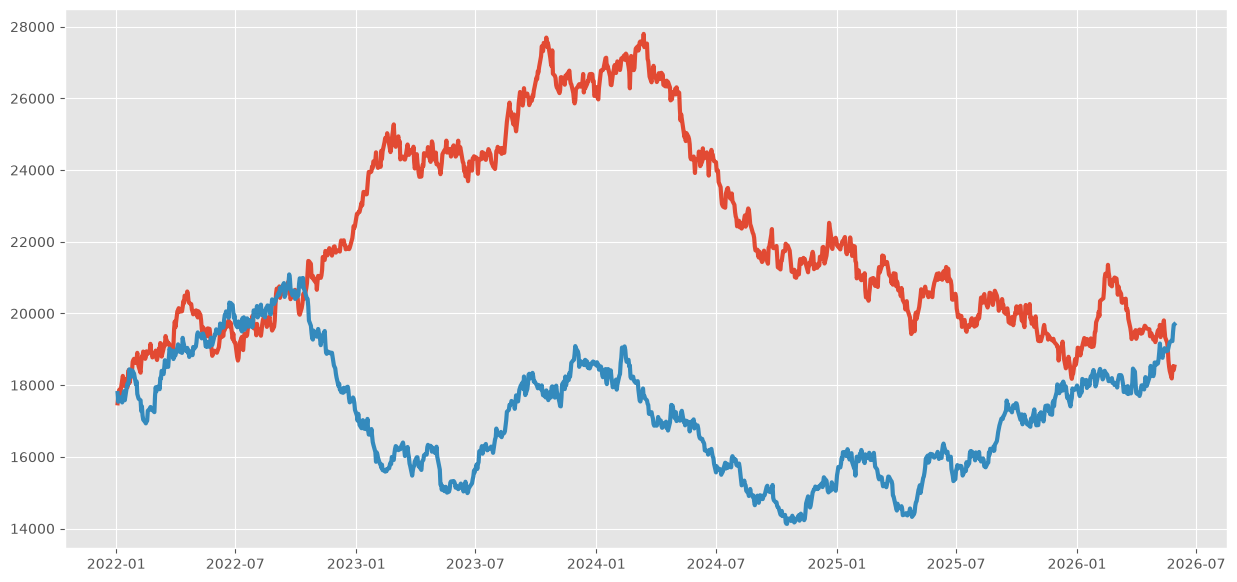

In [52]:
plt.figure(figsize=(15,7))

# Plot benchmarks
for idx in benchmark_filtered["index_name"].unique():

    temp = benchmark_filtered[
        benchmark_filtered["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        linewidth=3,
        label=idx
    )

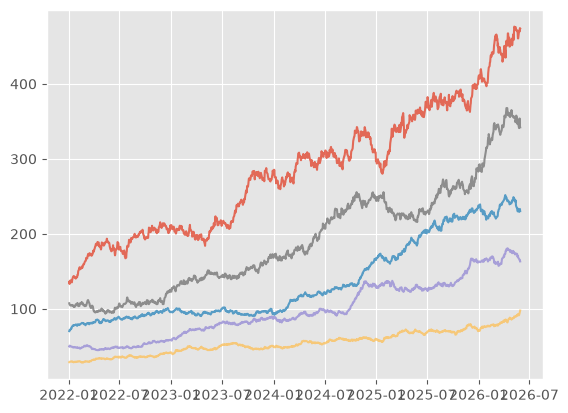

In [53]:
for fund_code in top5:

    temp = top5_nav[
        top5_nav["amfi_code"] == fund_code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.8
    )

/var/folders/8f/mjm056zx42b5bhk7b1dyf1h40000gn/T/ipykernel_94801/398876145.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


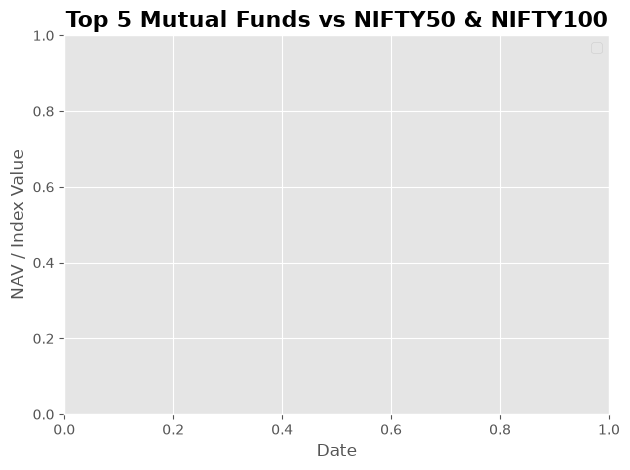

In [54]:
plt.title(
    "Top 5 Mutual Funds vs NIFTY50 & NIFTY100",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel("NAV / Index Value")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../Charts/benchmark_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
benchmark_returns = benchmark_filtered.copy()

benchmark_returns = benchmark_returns.sort_values(
    ["index_name", "date"]
)

benchmark_returns["benchmark_return"] = (
    benchmark_returns.groupby("index_name")[
        "close_value"
    ].pct_change()
)

In [56]:
nifty100_returns = benchmark_returns[
    benchmark_returns["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

In [57]:
tracking_error = []

for fund_code in top5:

    temp = nav[
        nav["amfi_code"] == fund_code
    ][["date", "daily_return"]]

    merged = temp.merge(
        nifty100_returns,
        on="date"
    ).dropna()

    te = (
        (merged["daily_return"] -
         merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error.append({
        "amfi_code": fund_code,
        "tracking_error": te
    })

tracking_error = pd.DataFrame(tracking_error)

tracking_error

,amfi_code,tracking_error
0,120505,0.231968
1,148567,0.189664
2,120843,0.206425
3,100033,0.228699
4,148569,0.217365


## Benchmark Comparison

- Top-performing mutual funds were compared against NIFTY50 and NIFTY100.
- Tracking Error measures how closely each fund follows the benchmark.
- Lower Tracking Error indicates benchmark-like performance.
- Higher Tracking Error suggests active management and deviation from the benchmark.